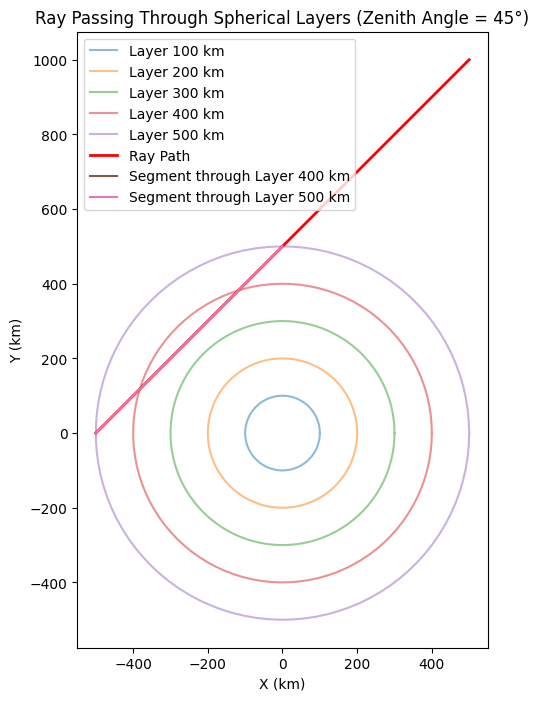

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate the intersection points between a ray and a circle
def ray_intersection(ray_origin, ray_angle, radius):
    """
    Given the ray's origin and angle, find the intersection with a circle of given radius.
    
    ray_origin: Tuple (x, y), coordinates of the ray's starting point
    ray_angle: Zenith angle of the ray in radians
    radius: Radius of the circle (layer)
    
    Returns the intersection points (x1, y1) and (x2, y2) on the circle, if they exist.
    """
    # Ray direction components (based on zenith angle)
    direction_x = np.sin(ray_angle)
    direction_y = np.cos(ray_angle)
    
    # The equation of the ray is: (x, y) = ray_origin + t * (direction_x, direction_y)
    # Equation of the circle: (x - 0)^2 + (y - 0)^2 = radius^2
    # Substituting the ray's equation into the circle's equation results in a quadratic equation
    
    a = direction_x**2 + direction_y**2
    b = 2 * (ray_origin[0] * direction_x + ray_origin[1] * direction_y)
    c = ray_origin[0]**2 + ray_origin[1]**2 - radius**2
    
    # Solve the quadratic equation
    discriminant = b**2 - 4 * a * c
    
    if discriminant < 0:
        return None  # No intersection
    
    sqrt_discriminant = np.sqrt(discriminant)
    
    # Solve for t (the parameter for the intersection points)
    t1 = (-b - sqrt_discriminant) / (2 * a)
    t2 = (-b + sqrt_discriminant) / (2 * a)
    
    # Get the intersection points (x, y)
    intersection_1 = (ray_origin[0] + t1 * direction_x, ray_origin[1] + t1 * direction_y)
    intersection_2 = (ray_origin[0] + t2 * direction_x, ray_origin[1] + t2 * direction_y)
    
    return intersection_1, intersection_2

# Parameters
radii = [100, 200, 300, 400, 500]  # Radii of spherical layers in km
zenith_angle = 45  # Zenith angle of the ray in degrees

# Convert the zenith angle to radians
ray_angle = np.radians(zenith_angle)

# Ray origin at the outermost layer (starting point)
ray_origin = (0, 500)  # The ray starts at radius 500 km along the x-axis

# Create a plot
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the spherical layers as concentric circles
theta = np.linspace(0, 2 * np.pi, 100)
for r in radii:
    ax.plot(r * np.cos(theta), r * np.sin(theta), label=f"Layer {r} km", alpha=0.5)

# Plot the ray path
ray_x = np.linspace(-500, 500, 100)
ray_y = ray_origin[1] + (ray_x - ray_origin[0]) * np.tan(ray_angle)
ax.plot(ray_x, ray_y, color='r', label="Ray Path", linewidth=2)

# Find and plot the intersections with each spherical layer
for r in radii:
    intersections = ray_intersection(ray_origin, ray_angle, r)
    if intersections:
        (x1, y1), (x2, y2) = intersections
        ax.plot([x1, x2], [y1, y2], label=f"Segment through Layer {r} km")

# Set labels and plot settings
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_title(f'Ray Passing Through Spherical Layers (Zenith Angle = {zenith_angle}°)')
ax.set_aspect('equal', 'box')
ax.legend()

# Display the plot
plt.show()
